# Project 3 — Sample notebook (Palmer penguins)

This pages explains how I generated the plot, summaries and insights for the sample project.

I chose four variables from the penguins dataset: species, island, flipper_length_mm, body_mass_g.

See [sample write-up](project-3-example-penguins.qmd), [Project 3 rubric](project-3.qmd), and [sample PDF](project-3-sample.pdf).


## Load data from TidyTuesday

1. Open the year list on GitHub (for example [2020 datasets](https://github.com/rfordatascience/tidytuesday/tree/main/data/2020)).
2. Click the week folder 2020-07-28 (Palmer penguins).
3. Open `readme.md` — read the description, source, and Data Dictionary (variable names and types).
4. Scroll to a section showing how to get the data, then copy the line with `read_csv('...')` URL.
5. In Colab: Runtime → Change runtime type → R. Run `library(tidyverse)`, paste `read_csv(...)`, then `glimpse()`.

Here's the Week page for the penguins: [2020-07-28](https://github.com/rfordatascience/tidytuesday/tree/main/data/2020/2020-07-28)


In [1]:
library(tidyverse)

# TidyTuesday week 2020-07-28 — URL copied from readme.md:
# https://github.com/rfordatascience/tidytuesday/tree/main/data/2020/2020-07-28

penguins <- read_csv(
  "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-07-28/penguins.csv"
)

glimpse(penguins)
head(penguins)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 344 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): species, island, sex
dbl (5): bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, year

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 344
Columns: 8
$ species           <chr> "Adelie", "Adelie", "Adelie", "Adelie", "Adelie", "A…
$ island            <chr> "Torgersen", "Torgersen", "Torgersen", "Torgersen", …
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34.1, …
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18.1, …
$ flipper_length_mm <dbl> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, 186…
$ body_mass_g       <dbl> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 3475, …
$ sex               <chr> "male", "female", "female", NA, "female", "male", "f…
$ year              <dbl> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


## Check missingness in the four variables

Before summarizing or plotting, count missing values in each of the four chosen variables and see how many rows are complete on all four.

In [2]:
# Missing values in each of the four chosen variables
penguins |>
  summarize(
    species_missing           = sum(is.na(species)),
    island_missing            = sum(is.na(island)),
    flipper_length_mm_missing = sum(is.na(flipper_length_mm)),
    body_mass_g_missing       = sum(is.na(body_mass_g))
  )

# Total rows in the full dataset
penguins |>
  summarize(total_rows = n())

# Keep only the four variables and drop rows with any missing values.
# Use penguins4 for every summary and plot below, so the rest of the code stays clean.
penguins4 <- penguins |>
  select(species, island, flipper_length_mm, body_mass_g) |>
  drop_na()

penguins4 |>
  summarize(complete_rows = n())

glimpse(penguins4)

species_missing,island_missing,flipper_length_mm_missing,body_mass_g_missing
<int>,<int>,<int>,<int>
0,0,2,2


total_rows
<int>
344


complete_rows
<int>
342


Rows: 342
Columns: 4
$ species           <chr> "Adelie", "Adelie", "Adelie", "Adelie", "Adelie", "A…
$ island            <chr> "Torgersen", "Torgersen", "Torgersen", "Torgersen", …
$ flipper_length_mm <dbl> 181, 186, 195, 193, 190, 181, 195, 193, 190, 186, 18…
$ body_mass_g       <dbl> 3750, 3800, 3250, 3450, 3650, 3625, 4675, 3475, 4250…


## Univariate 1/4 — species (categorical)

Counts, proportions, bar chart.


species,n,prop
<chr>,<int>,<dbl>
Adelie,151,0.4415205
Chinstrap,68,0.1988304
Gentoo,123,0.3596491


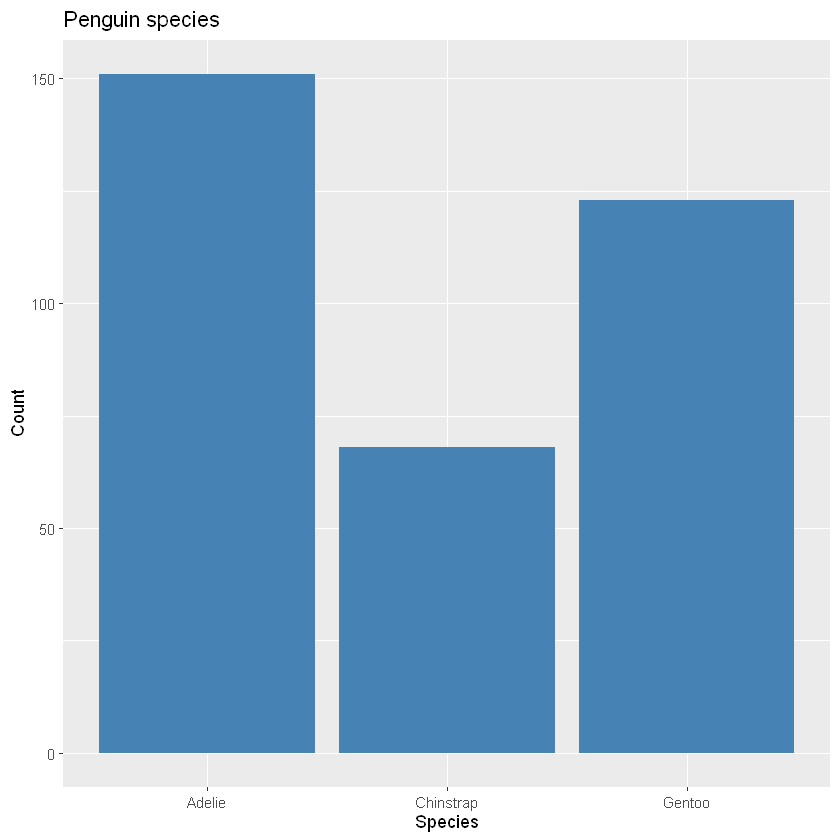

In [3]:
penguins4 |>
  count(species) |>
  mutate(prop = n / sum(n))

ggplot(penguins4, aes(x = species)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Penguin species", x = "Species", y = "Count")


## Univariate 2/4 — island (categorical)


island,n,prop
<chr>,<int>,<dbl>
Biscoe,167,0.4883041
Dream,124,0.3625731
Torgersen,51,0.1491228


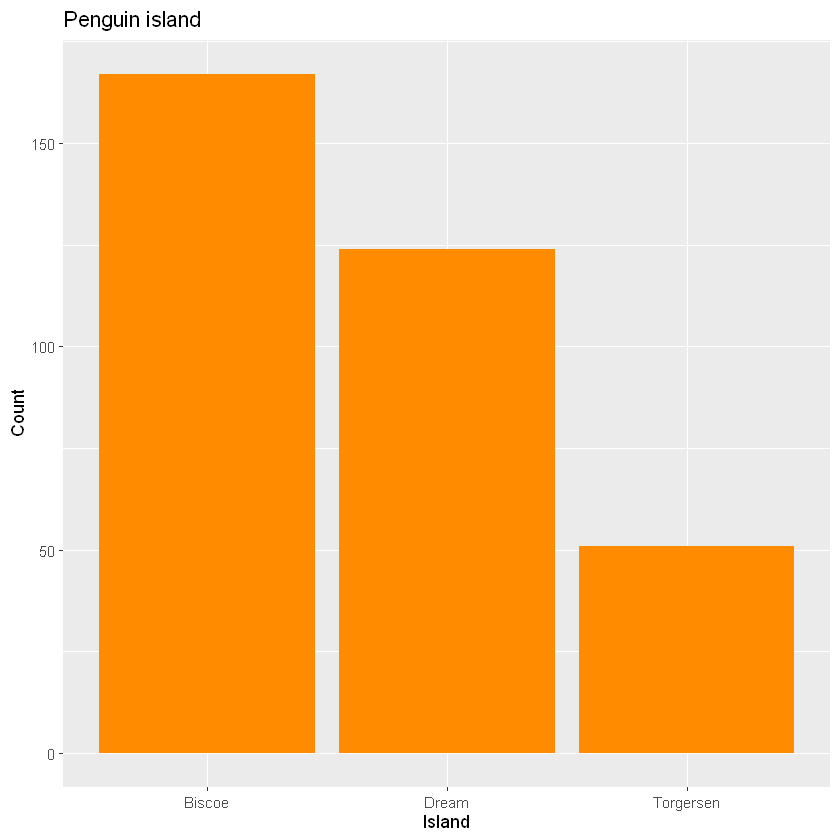

In [4]:
penguins4 |>
  count(island) |>
  mutate(prop = n / sum(n))

ggplot(penguins4, aes(x = island)) +
  geom_bar(fill = "darkorange") +
  labs(title = "Penguin island", x = "Island", y = "Count")


## Univariate 3/4 — flipper_length_mm (numerical)


n,mean,sd,median,IQR
<int>,<dbl>,<dbl>,<dbl>,<dbl>
342,200.9152,14.06171,197,23


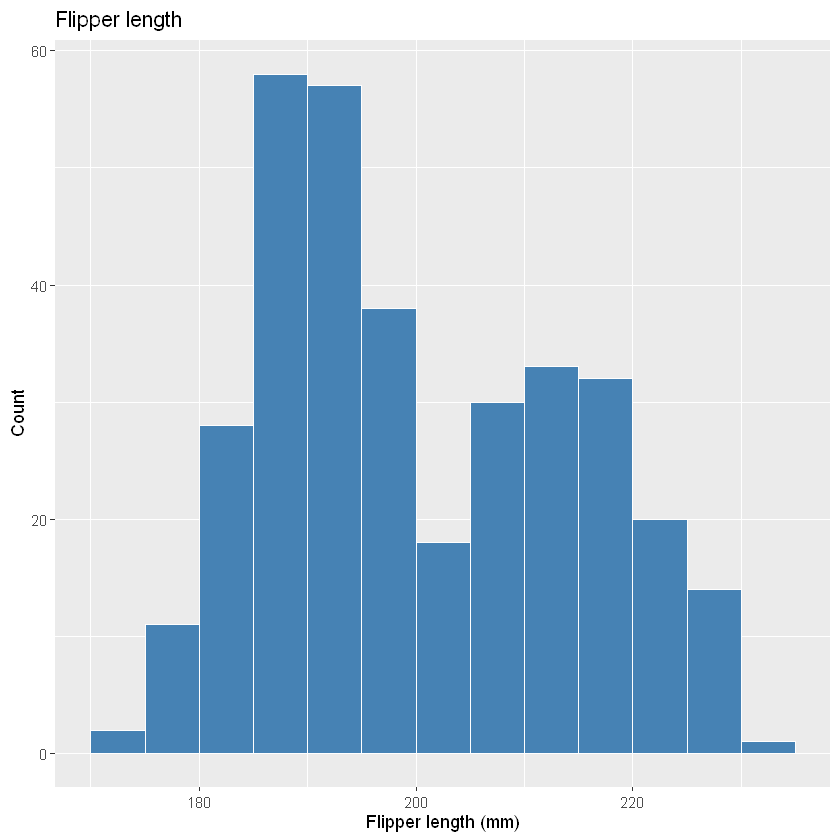

In [5]:
penguins4 |>
  summarize(
    n      = n(),
    mean   = mean(flipper_length_mm),
    sd     = sd(flipper_length_mm),
    median = median(flipper_length_mm),
    IQR    = IQR(flipper_length_mm)
  )

ggplot(penguins4, aes(x = flipper_length_mm)) +
  geom_histogram(binwidth = 5, boundary = 180, fill = "steelblue", color = "white") +
  labs(title = "Flipper length", x = "Flipper length (mm)", y = "Count")


## Univariate 4/4 — body_mass_g (numerical)


n,mean,sd,median,IQR
<int>,<dbl>,<dbl>,<dbl>,<dbl>
342,4201.754,801.9545,4050,1200


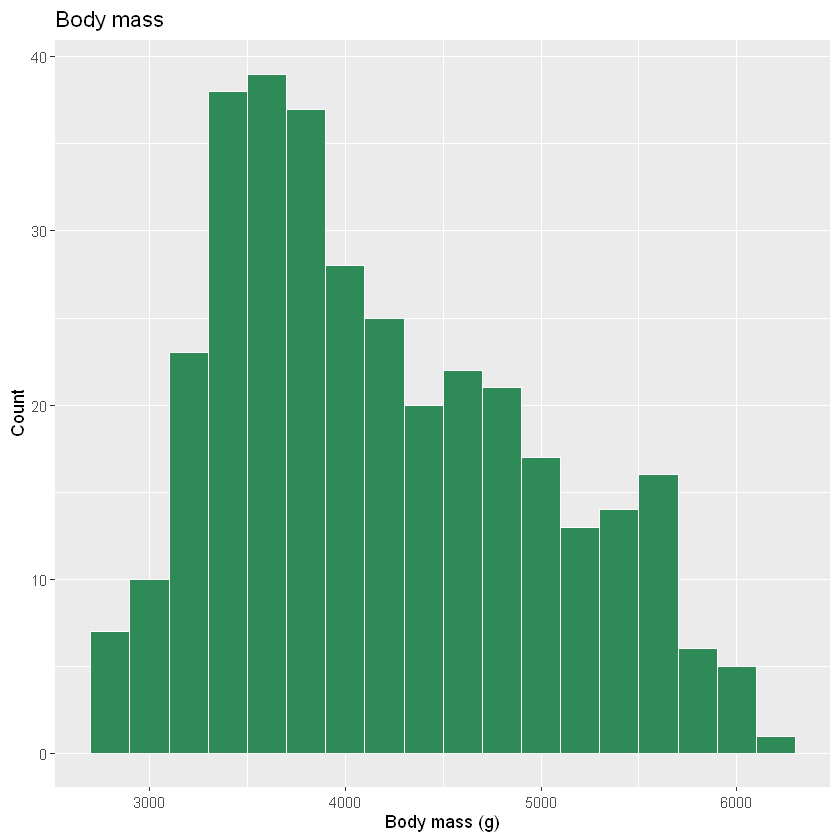

In [6]:
penguins4 |>
  summarize(
    n      = n(),
    mean   = mean(body_mass_g),
    sd     = sd(body_mass_g),
    median = median(body_mass_g),
    IQR    = IQR(body_mass_g)
  )

ggplot(penguins4, aes(x = body_mass_g)) +
  geom_histogram(binwidth = 200, fill = "seagreen", color = "white") +
  labs(title = "Body mass", x = "Body mass (g)", y = "Count")


## Bivariate pairs (6 plots)

All six pairs among the four variables. Pick two for the one-page summary (example choices at the end).


### Pair 1/6 — species × island (categorical × categorical)


species,Biscoe,Dream,Torgersen
<chr>,<int>,<int>,<int>
Adelie,44,56,51
Chinstrap,0,68,0
Gentoo,123,0,0


species,Biscoe,Dream,Torgersen
<chr>,<dbl>,<dbl>,<dbl>
Adelie,0.2634731,0.4516129,1
Chinstrap,0.0000000,0.5483871,0
Gentoo,0.7365269,0.0000000,0


species,Biscoe,Dream,Torgersen
<chr>,<dbl>,<dbl>,<dbl>
Adelie,0.2913907,0.3708609,0.3377483
Chinstrap,0.0000000,1.0000000,0.0000000
Gentoo,1.0000000,0.0000000,0.0000000


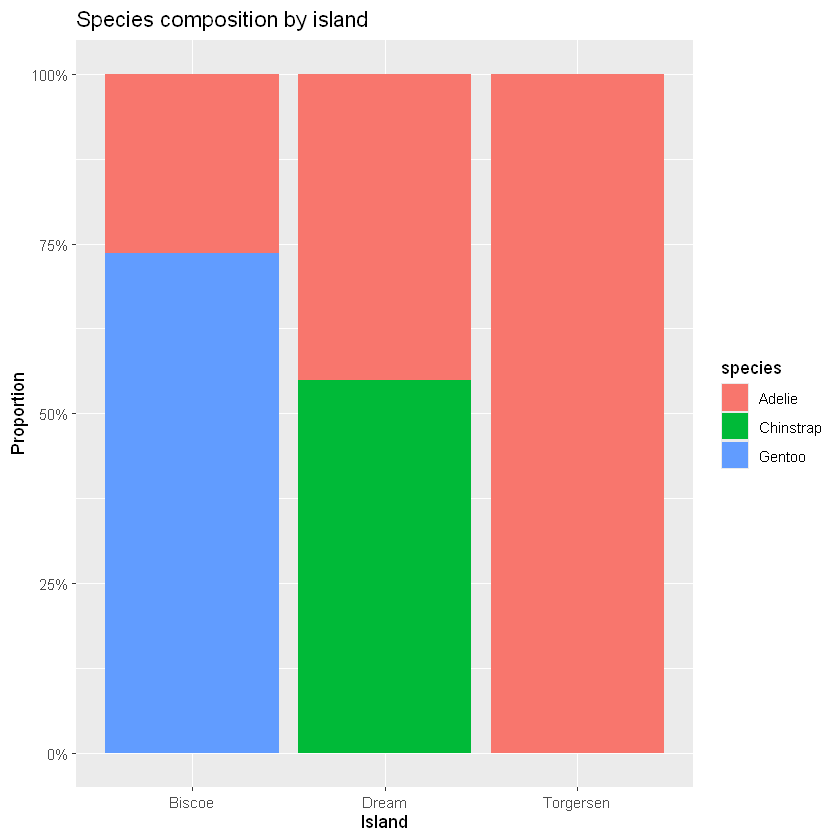

In [7]:
# Two-way table of counts
penguins4 |>
  count(species, island) |>
  pivot_wider(names_from = island, values_from = n, values_fill = 0)

# Column proportions: within each island, the share of each species (columns sum to 1)
penguins4 |>
  count(species, island) |>
  group_by(island) |>
  mutate(col_prop = n / sum(n)) |>
  select(species, island, col_prop) |>
  pivot_wider(names_from = island, values_from = col_prop, values_fill = 0)

# Row proportions: for each species, how it is distributed across islands (rows sum to 1)
penguins4 |>
  count(species, island) |>
  group_by(species) |>
  mutate(row_prop = n / sum(n)) |>
  select(species, island, row_prop) |>
  pivot_wider(names_from = island, values_from = row_prop, values_fill = 0)

ggplot(penguins4, aes(x = island, fill = species)) +
  geom_bar(position = "fill") +
  labs(title = "Species composition by island", x = "Island", y = "Proportion") +
  scale_y_continuous(labels = scales::percent)


### Pair 2/6 — flipper_length_mm by species (numerical × categorical)


species,n,mean,sd,median,IQR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,151,189.9536,6.539457,190,9
Chinstrap,68,195.8235,7.131894,196,10
Gentoo,123,217.1870,6.484976,216,9


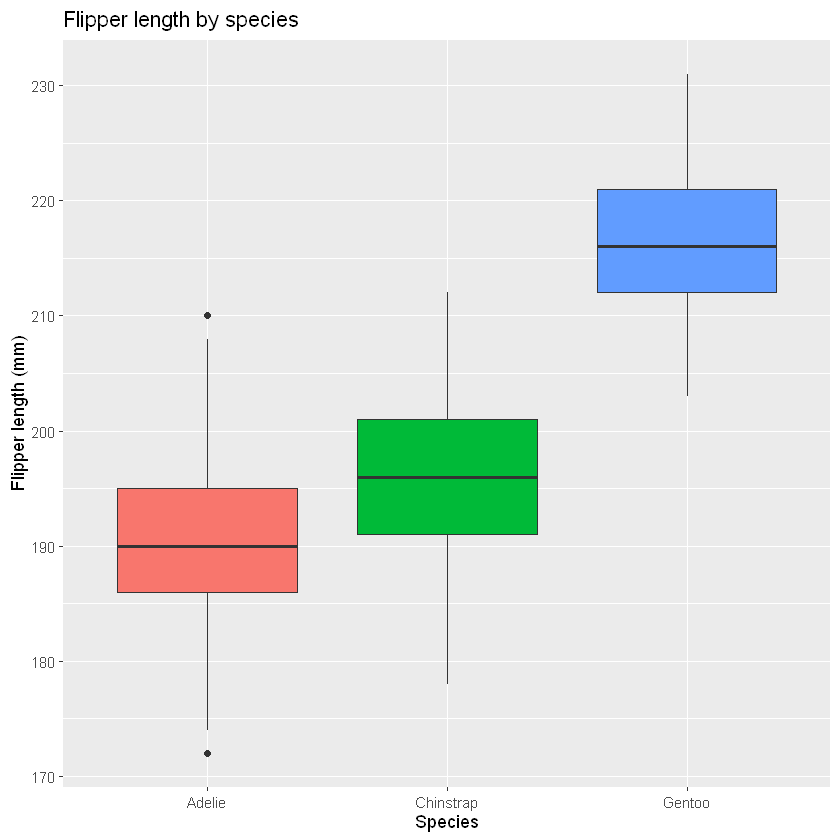

In [8]:
penguins4 |>
  group_by(species) |>
  summarize(
    n      = n(),
    mean   = mean(flipper_length_mm),
    sd     = sd(flipper_length_mm),
    median = median(flipper_length_mm),
    IQR    = IQR(flipper_length_mm)
  )

ggplot(penguins4, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  labs(title = "Flipper length by species", x = "Species", y = "Flipper length (mm)") +
  theme(legend.position = "none")


### Pair 3/6 — body_mass_g by species (numerical × categorical)


species,n,mean,sd,median,IQR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,151,3700.662,458.5661,3700,650.0
Chinstrap,68,3733.088,384.3351,3700,462.5
Gentoo,123,5076.016,504.1162,5000,800.0


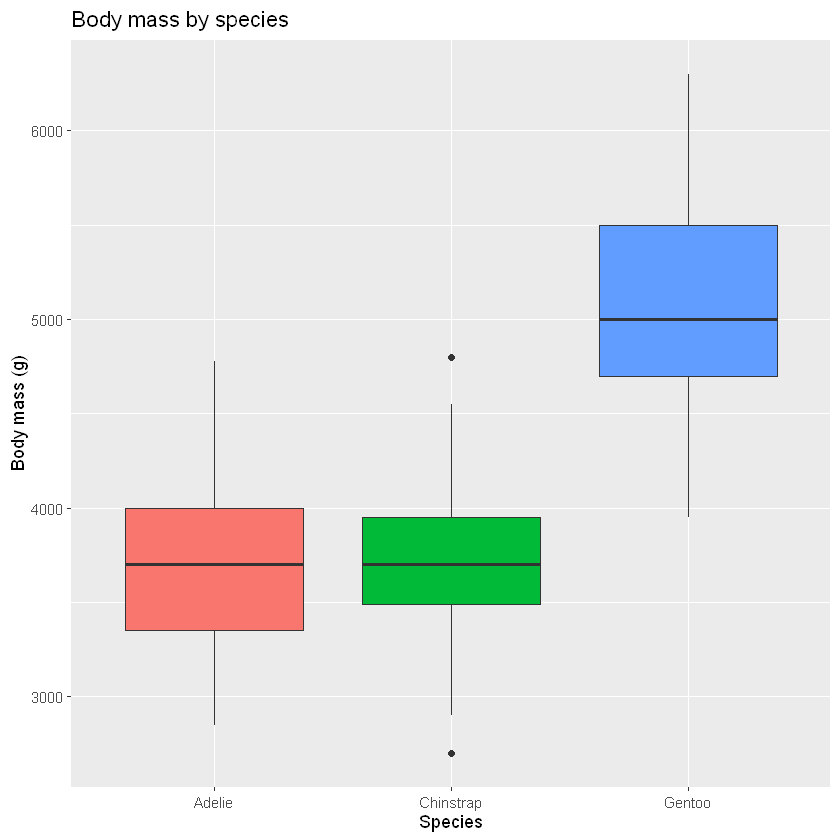

In [9]:
penguins4 |>
  group_by(species) |>
  summarize(
    n      = n(),
    mean   = mean(body_mass_g),
    sd     = sd(body_mass_g),
    median = median(body_mass_g),
    IQR    = IQR(body_mass_g)
  )

ggplot(penguins4, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Body mass by species", x = "Species", y = "Body mass (g)") +
  theme(legend.position = "none")


### Pair 4/6 — flipper_length_mm by island (numerical × categorical)


island,n,mean,sd,median,IQR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Biscoe,167,209.7066,14.142268,214,20.50
Dream,124,193.0726,7.507366,193,10.25
Torgersen,51,191.1961,6.232238,191,8.00


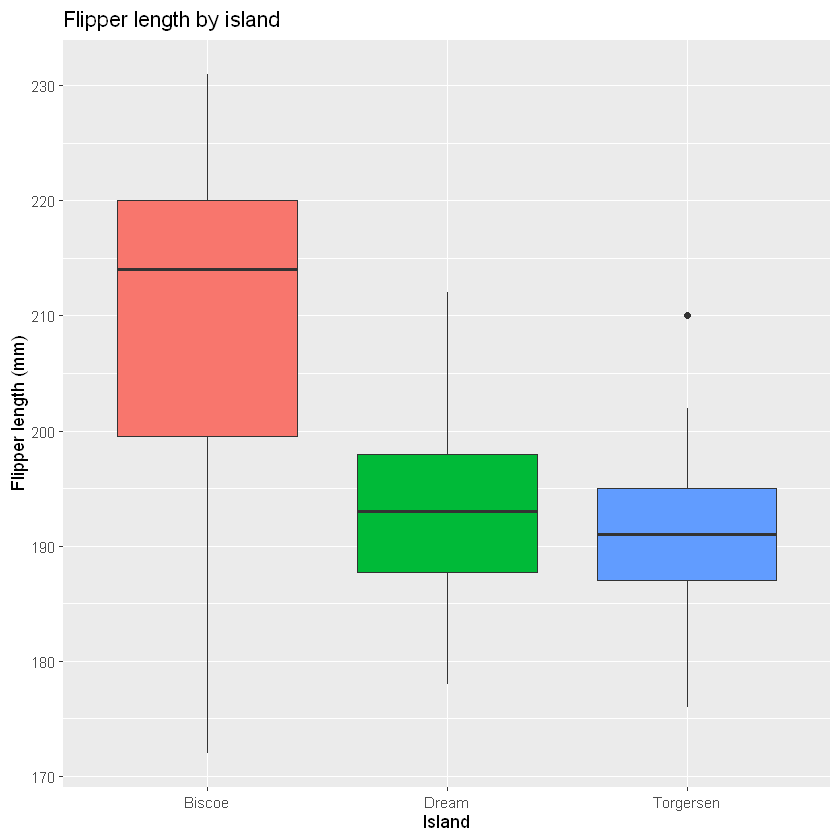

In [10]:
penguins4 |>
  group_by(island) |>
  summarize(
    n      = n(),
    mean   = mean(flipper_length_mm),
    sd     = sd(flipper_length_mm),
    median = median(flipper_length_mm),
    IQR    = IQR(flipper_length_mm)
  )

ggplot(penguins4, aes(x = island, y = flipper_length_mm, fill = island)) +
  geom_boxplot() +
  labs(title = "Flipper length by island", x = "Island", y = "Flipper length (mm)") +
  theme(legend.position = "none")


### Pair 5/6 — body_mass_g by island (numerical × categorical)


island,n,mean,sd,median,IQR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Biscoe,167,4716.018,782.8557,4775.0,1125.00
Dream,124,3712.903,416.6441,3687.5,556.25
Torgersen,51,3706.373,445.1079,3700.0,662.50


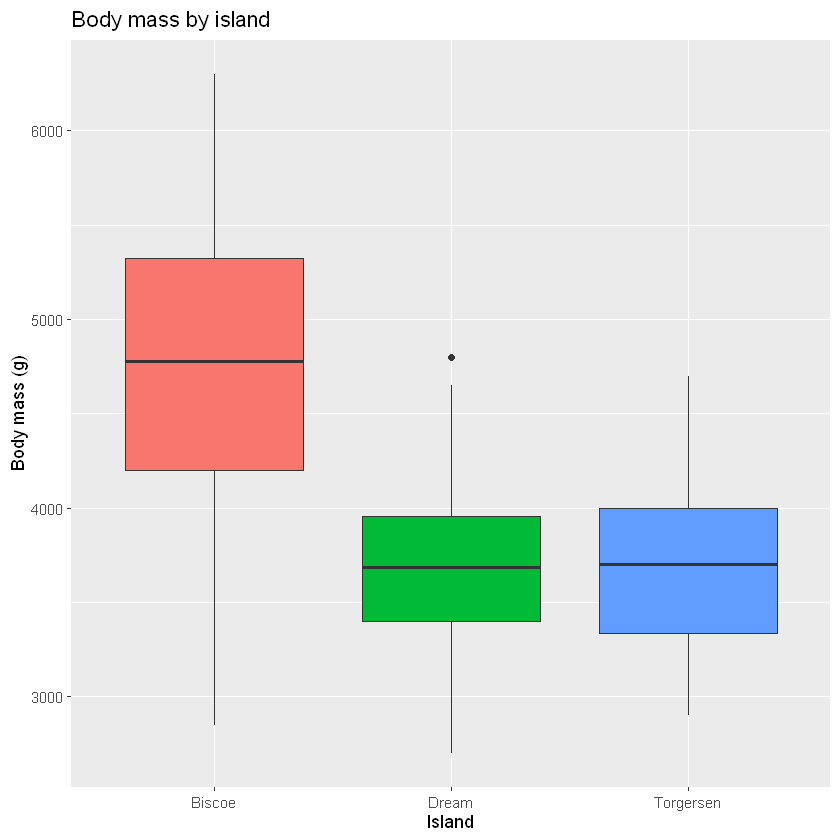

In [11]:
penguins4 |>
  group_by(island) |>
  summarize(
    n      = n(),
    mean   = mean(body_mass_g),
    sd     = sd(body_mass_g),
    median = median(body_mass_g),
    IQR    = IQR(body_mass_g)
  )

ggplot(penguins4, aes(x = island, y = body_mass_g, fill = island)) +
  geom_boxplot() +
  labs(title = "Body mass by island", x = "Island", y = "Body mass (g)") +
  theme(legend.position = "none")


### Pair 6/6 — flipper_length_mm vs body_mass_g (numerical × numerical)


r
<dbl>
0.8712018


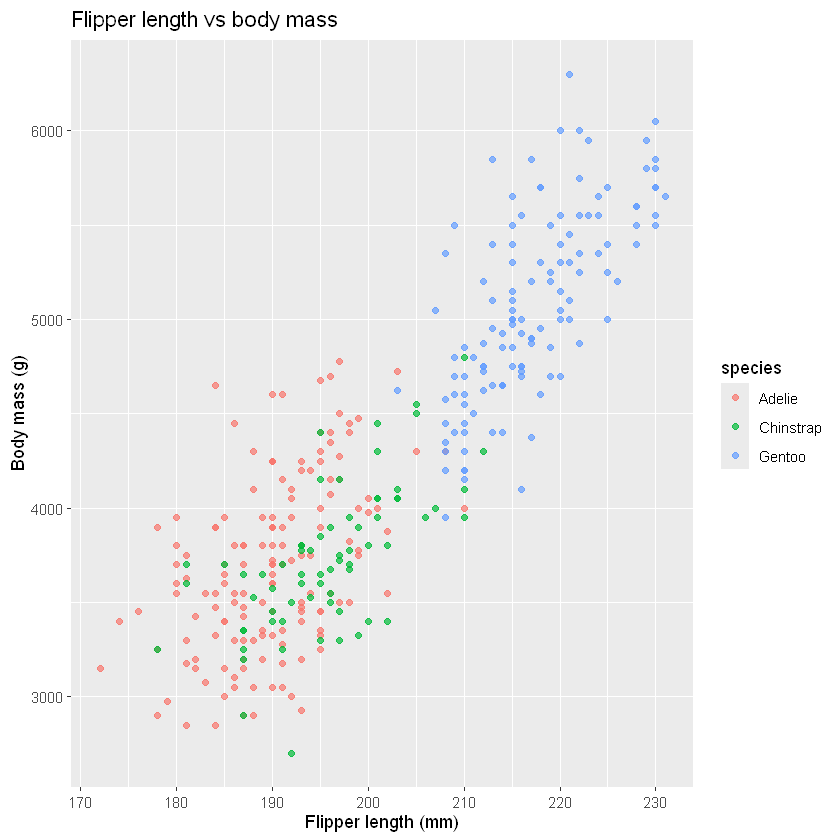

In [12]:
penguins4 |>
  summarize(r = cor(flipper_length_mm, body_mass_g))

ggplot(penguins4, aes(x = flipper_length_mm, y = body_mass_g, color = species)) +
  geom_point(alpha = 0.7) +
  labs(title = "Flipper length vs body mass", x = "Flipper length (mm)", y = "Body mass (g)")


## One-page summary (choices)

From the ten plots above, this sample would put on the one-pager:

1. Flipper length by species (pair 2/6).
2. Flipper length vs body mass (pair 6/6).


